### This notebook implements a self-pruning neural network using learnable gates and L1 sparsity regularization on CIFAR-10.

## 1. Imports

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

## 2. Prunable Linear Layer

In [19]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        
        # Standard weight and bias
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.01)
        self.bias = nn.Parameter(torch.zeros(out_features))
        
        # Learnable gate scores (same shape as weights)
        self.gate_scores = nn.Parameter(torch.randn(out_features, in_features))

    def forward(self, x):
        # Convert gate scores to values between 0 and 1
        gates = torch.sigmoid(self.gate_scores)
        
        # Apply gating to weights
        pruned_weights = self.weight * gates
        
        # Linear transformation
        return F.linear(x, pruned_weights, self.bias)

## 3. Model Definition

In [13]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = PrunableLinear(32*32*3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

## 4. Data Loading 

In [8]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

100%|███████████████████████████████████████████████████████████████████████████████| 170M/170M [02:26<00:00, 1.16MB/s]


## 5. Sparsity Loss

In [10]:
def sparsity_loss(model):
    loss = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            loss += gates.sum()
    return loss

## 6. Training

In [14]:
device = torch.device("cpu")

model = Net().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

lambda_val = 0.01

for epoch in range(2):  # keep small
    model.train()
    total_loss = 0

    for inputs, labels in trainloader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(inputs)
        ce_loss = F.cross_entropy(outputs, labels)
        sp_loss = sparsity_loss(model)

        loss = ce_loss + lambda_val * sp_loss
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 5617325.7598
Epoch 2, Loss: 3709602.1323


## 7. Evaluation

In [15]:
def evaluate(model):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in testloader:
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

print("Accuracy:", evaluate(model))

Accuracy: 37.55


In [16]:
def compute_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

print("Sparsity:", compute_sparsity(model))

Sparsity: 0.03375337533753375


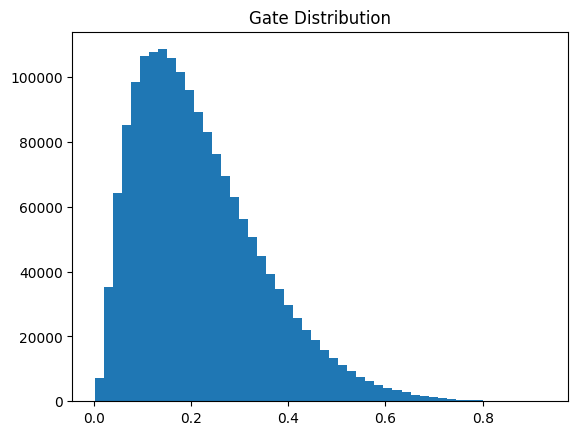

In [17]:
all_gates = []

for module in model.modules():
    if isinstance(module, PrunableLinear):
        gates = torch.sigmoid(module.gate_scores).detach().numpy().flatten()
        all_gates.extend(gates)

plt.hist(all_gates, bins=50)
plt.title("Gate Distribution")
plt.show()

## 8. Experiments (lambda loop)

In [24]:
# Final experiment: comparing multiple lambda values
results = []

for lambda_val in [0.001, 0.01, 0.1]:
    model = Net().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(2):
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            loss = F.cross_entropy(outputs, labels) + lambda_val * sparsity_loss(model)
            loss.backward()
            optimizer.step()

    acc = evaluate(model)
    sp = compute_sparsity(model)

    results.append((lambda_val, acc, sp))
    print(f"Lambda={lambda_val} | Accuracy={acc:.2f}% | Sparsity={sp:.2f}%")

Lambda=0.001 | Accuracy=38.92% | Sparsity=0.04%
Lambda=0.01 | Accuracy=39.54% | Sparsity=0.03%
Lambda=0.1 | Accuracy=36.77% | Sparsity=0.03%


## 9.Results

In [26]:
def compute_sparsity(model, threshold=1e-2):
    total = 0
    pruned = 0

    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total += gates.numel()
            pruned += (gates < threshold).sum().item()

    return 100 * pruned / total

print("Sparsity:", compute_sparsity(model))

Sparsity: 0.0330501800180018
